GPU: NVIDIA GeForce RTX 5070
CUDA version: (13, 2, 0)

Matrix size: 100 x 100
--------------------------------------------------
CPU multiplication... 0.1540 sec
GPU multiplication... 0.000370 sec

Matrix size: 200 x 200
--------------------------------------------------
CPU multiplication... 1.1934 sec
GPU multiplication... 0.000375 sec

Matrix size: 500 x 500
--------------------------------------------------
CPU multiplication... 18.9222 sec
GPU multiplication... 0.003490 sec

Matrix size: 800 x 800
--------------------------------------------------
CPU multiplication... 78.7539 sec
GPU multiplication... 0.006206 sec

Matrix size: 1000 x 1000
--------------------------------------------------
CPU multiplication... 160.2240 sec
GPU multiplication... 0.013873 sec

Matrix size: 2000 x 2000
--------------------------------------------------
CPU multiplication... 1247.5602 sec
GPU multiplication... 0.048922 sec

RESULTS SUMMARY
Size       CPU(s)       GPU(s)      
-----------------------

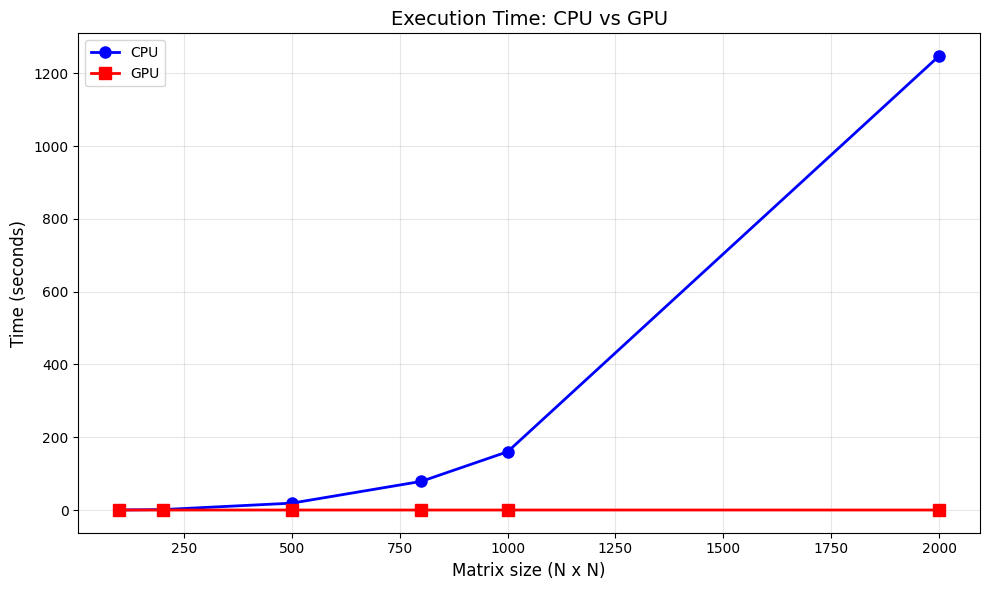

In [ ]:
import numpy as np
import pycuda.autoinit
import pycuda.driver as cuda
from pycuda.compiler import SourceModule
import time
import matplotlib.pyplot as plt

print(f"GPU: {cuda.Device(0).name()}")
print(f"CUDA version: {cuda.get_version()}")

def cpu_matrix_mult(A, B):
    """Matrix multiplication on CPU with triple loop"""
    N = A.shape[0]
    C = np.zeros((N, N), dtype=np.float32)
    
    start = time.perf_counter()
    for i in range(N):
        for j in range(N):
            total = 0.0
            for k in range(N):
                total += A[i, k] * B[k, j]
            C[i, j] = total
    end = time.perf_counter()
    
    return C, end - start

def gpu_matrix_mult(A, B):
    """Matrix multiplication on GPU with PyCUDA"""
    N = A.shape[0]
    
    kernel_code = """
    __global__ void matrixMulKernel(float *A, float *B, float *C, int N) {
        int row = blockIdx.y * blockDim.y + threadIdx.y;
        int col = blockIdx.x * blockDim.x + threadIdx.x;
        
        if(row < N && col < N) {
            float sum = 0.0;
            for (int k = 0; k < N; k++) {
                sum += A[row * N + k] * B[k * N + col];
            }
            C[row * N + col] = sum;
        }
    }
    """
    
    mod = SourceModule(kernel_code)
    matrix_mul = mod.get_function("matrixMulKernel")
    
    block_size = (16, 16, 1)
    grid_size = (int(np.ceil(N / 16)), int(np.ceil(N / 16)), 1)
    
    A_gpu = cuda.mem_alloc(A.nbytes)
    B_gpu = cuda.mem_alloc(B.nbytes)
    C_gpu = cuda.mem_alloc(A.nbytes)
    
    start = time.perf_counter()
    
    cuda.memcpy_htod(A_gpu, A)
    cuda.Context.synchronize()
    
    cuda.memcpy_htod(B_gpu, B)
    cuda.Context.synchronize()
    
    matrix_mul(A_gpu, B_gpu, C_gpu, np.int32(N), 
               block=block_size, grid=grid_size)
    cuda.Context.synchronize()
    
    result = np.empty_like(A)
    cuda.memcpy_dtoh(result, C_gpu)
    cuda.Context.synchronize()
    
    end = time.perf_counter()
    total_time = end - start
    
    A_gpu.free()
    B_gpu.free()
    C_gpu.free()
    
    return result, total_time


test_sizes = [100, 200, 500, 800, 1000, 2000]


results = []

for size in test_sizes:
    print(f"\nMatrix size: {size} x {size}")
    print("-" * 50)
    
    A = np.random.rand(size, size).astype(np.float32)
    B = np.random.rand(size, size).astype(np.float32)
    
    print("CPU multiplication...", end=" ", flush=True)
    C_cpu, cpu_time = cpu_matrix_mult(A, B)
    print(f"{cpu_time:.4f} sec")
    
    print("GPU multiplication...", end=" ", flush=True)
    C_gpu, gpu_time = gpu_matrix_mult(A, B)
    print(f"{gpu_time:.6f} sec")
    
    results.append({
        'size': size,
        'cpu_time': cpu_time,
        'gpu_time': gpu_time
    })

print("\n" + "=" * 70)
print("RESULTS SUMMARY")
print("=" * 70)
print(f"{'Size':<10} {'CPU(s)':<12} {'GPU(s)':<12}")
print("-" * 40)

for r in results:
    print(f"{r['size']:<10} {r['cpu_time']:<12.4f} {r['gpu_time']:<12.6f}")


fig, ax = plt.subplots(1, 1, figsize=(10, 6))

sizes = [r['size'] for r in results]
cpu_times = [r['cpu_time'] for r in results]
gpu_times = [r['gpu_time'] for r in results]


ax.plot(sizes, cpu_times, 'o-', label='CPU', linewidth=2, markersize=8, color='blue')
ax.plot(sizes, gpu_times, 's-', label='GPU', linewidth=2, markersize=8, color='red')
ax.set_xlabel('Matrix size (N x N)', fontsize=12)
ax.set_ylabel('Time (seconds)', fontsize=12)
ax.set_title('Execution Time: CPU vs GPU', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('matrix_results.png', dpi=300, bbox_inches='tight')
plt.show()
